<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 2: Clustering por Gaussian Mixture Models</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> En esta actividad construiras un clustering basado en GMM.
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales: leea y responda los siguientes incisos</b>
<ul>
</ul>
</div>

**1.** Utilice GMM para la segmentación de clientes en el análisis de la cesta de la compra del siguiente dataset `customer_shopping.csv`. Emplee GMM para agrupar a los clientes según su comportamiento de compra. Una vez agrupados, podrá crear promociones dirigidas y recomendaciones personalizadas para cada segmento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

import warnings
warnings.filterwarnings("ignore")

##Cargamos el dataset

In [47]:
df_customer = pd.read_csv('customer_shopping.csv')
df_customer.info()
df_customer.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Customer  84 non-null     object
 1   Bread     84 non-null     int64 
 2   Milk      84 non-null     int64 
 3   Eggs      84 non-null     int64 
 4   Beer      84 non-null     int64 
 5   Chips     84 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 4.1+ KB


,Customer,Bread,Milk,Eggs,Beer,Chips
0,c001,12,10,8,0,1
1,c002,10,8,7,1,0
2,c003,11,9,6,0,1
3,c004,1,2,1,10,8
4,c005,0,1,2,12,10


In [48]:
faltante_c = df_customer.isnull().sum()
print(f"Total de valores nulos: ,{faltante_c}")

Total de valores nulos: ,Customer    0
Bread       0
Milk        0
Eggs        0
Beer        0
Chips       0
dtype: int64


##Escalamiento y selección de características, utilice las columnas 'Bread','Milk','Eggs','Beer','Chips'

Para ello, se deben preparar las variables por lo que se debe eliminar de las columnas 'Customer' porque es un string.

In [73]:
#Aquí eliminamos la columna 'Customer'
columns_productos = ['Bread','Milk','Eggs','Beer','Chips']
datos = df_customer[columns_productos]
print(datos.head())

   Bread  Milk  Eggs  Beer  Chips
0     12    10     8     0      1
1     10     8     7     1      0
2     11     9     6     0      1
3      1     2     1    10      8
4      0     1     2    12     10


In [91]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

normal=MinMaxScaler()
X = normal.fit_transform(datos)


## Entrene el modelo por GMM utilice métricas para saber cuantos componentes elegir

In [100]:
from sklearn.mixture import GaussianMixture
#Se probo con 4, 6 y 10 componentes
#Nos quedamos con 4

gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm.fit(X)
labels = gmm.predict(X)                         # asignación dura (cluster más probable)
probabilidad = gmm.predict_proba(X)             # asignación suave (probabilidades)

print('Pesos de la mezcla:', np.round(gmm.weights_, 3))
print('Probabilidades de los primeros 10 Clientes:\n', np.round(probabilidad[:10], 4))


Pesos de la mezcla: [0.381 0.236 0.238 0.145]
Probabilidades de los primeros 10 Clientes:
 [[1.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 9.998e-01 0.000e+00 2.000e-04]
 [0.000e+00 9.842e-01 0.000e+00 1.580e-02]
 [0.000e+00 1.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 1.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 1.000e+00 0.000e+00 0.000e+00]]


In [101]:
from sklearn.metrics import silhouette_score

predicciones = gmm.predict(X)
responsabilidades = gmm.predict_proba(X)
print(f'Log-verosimilitud media: {gmm.score(X):.3f}')
print(f'Convergencia: {gmm.converged_} en {gmm.n_iter_} iteraciones')
print(f'Silueta de las etiquetas duras: {silhouette_score(X, predicciones):.3f}')

# Las filas de la matriz de responsabilidades siempre deben sumar 1.
print('Suma de responsabilidades, primeras 10 observaciones:', responsabilidades[:3].sum(axis=1).round(10))

Log-verosimilitud media: 4.056
Convergencia: True en 2 iteraciones
Silueta de las etiquetas duras: 0.473
Suma de responsabilidades, primeras 10 observaciones: [1. 1. 1.]


In [117]:
# Muestre el perfil de los clusters
df_perfil = df_customer[['Customer', 'Bread', 'Milk', 'Eggs', 'Beer', 'Chips']].copy()
df_perfil['Cluster'] = labels
print(df_perfil.head())

  Customer  Bread  Milk  Eggs  Beer  Chips  Cluster
0     c001     12    10     8     0      1        0
1     c002     10     8     7     1      0        0
2     c003     11     9     6     0      1        0
3     c004      1     2     1    10      8        1
4     c005      0     1     2    12     10        1


In [115]:
# Calculo el promedio por variable de cada clúster del dataframe
df_perfil = df_customer[columns_productos].copy()
df_perfil['Cluster'] = labels
perfil_clusters = df_perfil.groupby('Cluster')[columns_productos].mean()

print(perfil_clusters.round(2))

         Bread  Milk  Eggs   Beer  Chips
Cluster                                 
0        12.06  9.34  7.41   0.78   0.84
1         1.30  1.00  1.05  11.10   7.80
2         5.00  5.05  4.05   4.10   3.65
3         1.42  2.08  0.75   9.92  11.08


In [116]:
tamaño_clusters = df_perfil['Cluster'].value_counts().sort_index()

print("Número de clientes por cluster:")
print(tamaño_clusters)

Número de clientes por cluster:
Cluster
0    32
1    20
2    20
3    12
Name: count, dtype: int64


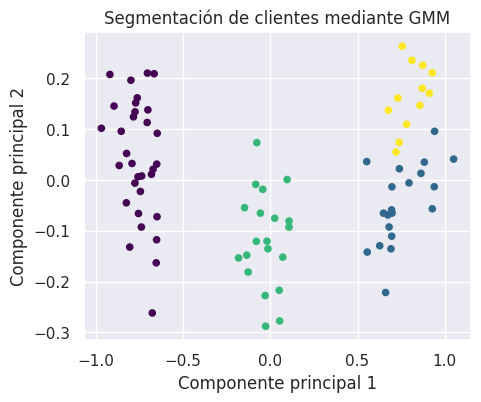

In [104]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_cn = pd.DataFrame(X_pca, columns=['X', 'Y'])

df_cn['Cluster'] = labels

plt.figure(figsize=(5, 4))
plt.scatter(df_cn['X'], df_cn['Y'], c=df_cn['Cluster'], cmap='viridis', s=20)
plt.title('Segmentación de clientes mediante GMM')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')

plt.show()

In [105]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Customer  84 non-null     object
 1   Bread     84 non-null     int64 
 2   Milk      84 non-null     int64 
 3   Eggs      84 non-null     int64 
 4   Beer      84 non-null     int64 
 5   Chips     84 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 4.1+ KB


In [120]:
# Cree un nuevo cliente con la misma estructura del dataframe original
nuevo_cliente = pd.DataFrame({
    'Customer': ['Cliente_Nuevo'],
    'Bread': [5],
    'Milk': [2],
    'Eggs': [4],
    'Beer': [0],
    'Chips': [3]
})

print(nuevo_cliente)


        Customer  Bread  Milk  Eggs  Beer  Chips
0  Cliente_Nuevo      5     2     4     0      3


In [122]:
nuevo_cliente_X = nuevo_cliente[columns_productos]
print(nuevo_cliente_X)

   Bread  Milk  Eggs  Beer  Chips
0      5     2     4     0      3


In [136]:
# Prediga el cluster al que pertenece este nuevo cliente

cluster_cliente_nuevo = gmm.predict(nuevo_cliente_X)
print(f"Clúster del nuevo cliente: {cluster_cliente_nuevo[0]}")

predict_proba = gmm.predict_proba(nuevo_cliente_X)
print(f"Probabilidad de pertenencia a cada clúster: {(np.round(predict_proba,4))}")

Clúster del nuevo cliente: 0
Probabilidad de pertenencia a cada clúster: [[1. 0. 0. 0.]]


In [ ]:
# En función al resultado, cree una recomendación a este nuevo cliente
# De acuerdo a cada perfil de clúster, al pertencer al [0], indica:
# Consume demasiado BREAD, EGGS y MILK, por lo que la promoción puede
# ser para el desayuno, en la compra de los tres productos.

**2.-**  Obtenga un modelo de clustering para el dataset `healthcare_dataset.csv` para obtener una agrupación de pacientes sanitarios mediante GMM: Los hospitales a menudo necesitan agrupar a pacientes con características similares para: identificar pacientes de alto riesgo, personalizar planes de tratamiento, optimizar la asignación de recursos y mejorar la gestión sanitaria.

In [3]:
#Cargamos el dataset
df_health = pd.read_csv('healthcare_dataset.csv')
df_health.info()
df_health.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
faltante_h = df_health.isnull().sum()
print(f"Total de valores nulos: ,{faltante_h}")

Total de valores nulos: ,Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


# Escalamiento y selección de características

In [ ]:
# ¿Qué hacemos si tenemos columnas categoricas y numéricas y queremos utilizarlas en el clustering?
# hay que convertir y transformar a números

In [5]:
#Puedo identificar cuantas categorías tiene cada variable
df_health.nunique()

,0
Name,49992
Age,77
Gender,2
Blood Type,8
Medical Condition,6
Date of Admission,1827
Doctor,40341
Hospital,39876
Insurance Provider,5
Billing Amount,50000


In [6]:
#Identificar cuales son las categorías de las variables
for col in df_health.columns:
    print(df_health[col].value_counts().head(10))
    print('-' * 30)

Name
DAvId muNoZ              3
Cody BurNett             2
roDNEy Shaw              2
grEGorY smitH            2
MelisSA coOk             2
MiCHael LeE              2
pETEr bakER              2
TInA THompsoN            2
mrS. gabRieLa piTTmAn    2
EmiLY CALlahAN           2
Name: count, dtype: int64
------------------------------
Age
38    897
37    893
57    887
34    864
80    864
56    856
66    856
58    852
43    847
53    845
Name: count, dtype: int64
------------------------------
Gender
Male      27774
Female    27726
Name: count, dtype: int64
------------------------------
Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
B-     6944
O+     6917
O-     6877
Name: count, dtype: int64
------------------------------
Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64
------------------------------
Date of Admission
2024-03-16    50
2022-07-24 

In [ ]:
# Para el procesamiento de la información no voy a utlizar todas las columnas (variables) por lo que hay que analizar cual nos sirven y cual no
# Descarto:
# 'Name','Room Number','Doctor','Hospital' no se pueden categorizar y no proporcionan mayor información.

# Conservo:
# Se pueden categorizar y ordenar
# 'Age', puedo obtener características niño, adulto y adulto mayor.
# 'Billing Amount' podemos obtener promedio o desviaciones de gastos o costo de atención.
# 'Date of Admission', 'Discharge Date', nos puede dar el tiempo de estancia.
# 'Gender', para clasificar hombre o mujer.
# 'Blood Type', se puede clasificar, o tipos de sangre.
# 'Medical condition', dice el perfil exacto del paciente, tiene 6 categorías.
# 'Admission Type', tiene 3 categorías.
# 'Insurance Provider', tiene 5 categorías.
# 'Medication' tiene 5 categorías.
# 'Test Resultados' tiene 3 categorías.


In [7]:
# Acción para obtener la estancia del paciente
df_health["Date of Admission"] = pd.to_datetime(df_health["Date of Admission"])
df_health["Discharge Date"] = pd.to_datetime(df_health["Discharge Date"])

df_health["Length of Stay"] = (
    df_health["Discharge Date"] -
    df_health["Date of Admission"]
).dt.days

print("\nEstancia en días:")
print(df_health["Length of Stay"].describe())


Estancia en días:
count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64


In [8]:
columnas_eliminar = ["Name", "Room Number", "Doctor", "Hospital", "Date of Admission", "Discharge Date"]
df_health = df_health.drop(columns=columnas_eliminar)

In [9]:
df_health.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Length of Stay
0,30,Male,B-,Cancer,Blue Cross,18856.281306,Urgent,Paracetamol,Normal,2
1,62,Male,A+,Obesity,Medicare,33643.327287,Emergency,Ibuprofen,Inconclusive,6
2,76,Female,A-,Obesity,Aetna,27955.096079,Emergency,Aspirin,Normal,15
3,28,Female,O+,Diabetes,Medicare,37909.782410,Elective,Ibuprofen,Abnormal,30
4,43,Female,AB+,Cancer,Aetna,14238.317814,Urgent,Penicillin,Abnormal,20


In [44]:
# Se revisa que las columnas numéricas no haya datos negativos:
print("Valores negativos de Age:", (df_health["Age"] < 0).sum())
print("Valores negativos de Billing Amount:", (df_health["Billing Amount"] < 0).sum())
print("Valores negativos de Length of Stay:", (df_health["Length of Stay"] < 0).sum())

Valores negativos de Age: 0
Valores negativos de Billing Amount: 108
Valores negativos de Length of Stay: 0


In [12]:
# Como si hay en Billing Amount
# Resultaron 108 es una mínima parte, prefiero eliminarlos y quedarme con los montos de facturación positivos >0.
# defini otro DataFrame
df_hn = df_health[df_health["Billing Amount"] >= 0].copy()

In [13]:
#Comprobación de eliminación de registros
print(df_hn.shape)
print((df_hn["Billing Amount"] < 0).sum())

(55392, 10)
0


In [14]:
df_hn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55392 entries, 0 to 55499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 55392 non-null  int64  
 1   Gender              55392 non-null  object 
 2   Blood Type          55392 non-null  object 
 3   Medical Condition   55392 non-null  object 
 4   Insurance Provider  55392 non-null  object 
 5   Billing Amount      55392 non-null  float64
 6   Admission Type      55392 non-null  object 
 7   Medication          55392 non-null  object 
 8   Test Results        55392 non-null  object 
 9   Length of Stay      55392 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 4.6+ MB


In [46]:
#Separar variables numéricas y categóricas para procesar agrupadas todas las columnas.
columnas_numericas = ["Age","Billing Amount","Length of Stay"]
columnas_categoricas = ["Gender","Blood Type","Medical Condition","Insurance Provider","Admission Type","Medication","Test Results"]

#Para procesar las columnas numéricas se utilizará StandardScaler()
#Para procesar las columns categóricas se utilizará OneHotEncoder()

In [16]:
columnas_numericas

['Age', 'Billing Amount', 'Length of Stay']

In [17]:
columnas_categoricas

['Gender',
 'Blood Type',
 'Medical Condition',
 'Insurance Provider',
 'Admission Type',
 'Medication',
 'Test Results']

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [19]:
# Junto los dos grupos de categorías con el ColumnTransformer:
preprocesador = ColumnTransformer(transformers=[
        ("numericas", StandardScaler(), columnas_numericas),
        ("categoricas", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)])

In [20]:
X = preprocesador.fit_transform(df_hn)
X_dense = X.toarray()

In [21]:
# Entrene el modelo por GMM utilice métricas para saber cuantos componentes elegir y cree una columna para asignar el cluster
from sklearn.mixture import GaussianMixture

In [22]:
gmm_10 = GaussianMixture(n_components=10, covariance_type='full', random_state=42)
gmm_10.fit(X_dense)
labels = gmm_10.predict(X_dense)                         # asignación dura (cluster más probable)
probabilidad = gmm_10.predict_proba(X_dense)             # asignación suave (probabilidades)

print('Pesos de la mezcla:', np.round(gmm_10.weights_, 4))
print('Probabilidades de los 10 primeros pacientes:\n', np.round(probabilidad[:10], 6))

df_hn["Cluster"] = labels

print("\nCantidad de pacientes por cluster:") #Aportación de IA
print(df_hn["Cluster"].value_counts().sort_index())

Pesos de la mezcla (pi_k): [0.0045 0.0814 0.0825 0.2318 0.1034 0.1873 0.1355 0.0115 0.0439 0.1183]
Probabilidades de los 10 primeros pacientes:
 [[0.00000e+00 9.96875e-01 0.00000e+00 3.12500e-03 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  9.99982e-01 0.00000e+00 0.00000e+00 1.80000e-05]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 2.00000e-06 0.00000e+00
  9.99998e-01 0.00000e+00 0.000

In [23]:
#Promedio de las columnas numéricas
perfil_numerico = df_hn.groupby("Cluster")[["Age", "Billing Amount", "Length of Stay"]].mean()
print(perfil_numerico.round(2))

           Age  Billing Amount  Length of Stay
Cluster                                       
0        49.81        26234.05           16.29
1        51.82        25755.05           15.41
2        51.50        25752.56           15.63
3        51.39        25536.19           15.53
4        51.32        26141.72           15.36
5        51.81        25435.78           15.53
6        51.57        25356.38           15.26
7        51.04        25991.81           15.98
8        50.61        25665.34           15.84
9        51.83        25408.43           15.64


In [24]:
#Cree una tabla para mostrar como queda los Clúster con las columnas categóricas
tabla_categoricas = pd.DataFrame()

for variable in columnas_categoricas:
    valores = (df_hn.groupby("Cluster")[variable].agg(lambda x: x.mode().iloc[0]))

    tabla_categoricas[variable] = valores

tabla_categoricas = tabla_categoricas.T # Transponer para que las variables sean filas
tabla_categoricas.columns = [f"Clúster {c}" for c in tabla_categoricas.columns]

tabla_categoricas

,Clúster 0,Clúster 1,Clúster 2,Clúster 3,Clúster 4,Clúster 5,Clúster 6,Clúster 7,Clúster 8,Clúster 9
Gender,Female,Male,Male,Female,Female,Female,Female,Female,Male,Female
Blood Type,A-,B-,AB+,A+,O-,B+,O+,A+,AB+,AB+
Medical Condition,Obesity,Obesity,Obesity,Hypertension,Obesity,Cancer,Arthritis,Obesity,Hypertension,Obesity
Insurance Provider,Blue Cross,Medicare,Medicare,Cigna,Medicare,UnitedHealthcare,Medicare,Medicare,Medicare,Medicare
Admission Type,Urgent,Urgent,Urgent,Elective,Elective,Elective,Elective,Emergency,Urgent,Emergency
Medication,Lipitor,Paracetamol,Ibuprofen,Ibuprofen,Penicillin,Aspirin,Penicillin,Lipitor,Penicillin,Paracetamol
Test Results,Abnormal,Abnormal,Abnormal,Normal,Abnormal,Normal,Abnormal,Inconclusive,Inconclusive,Abnormal


In [25]:
# Cree un nuevo paciente con algunos valores en base a las columnas elegidas
nuevo_paciente = pd.DataFrame({
    "Age": [49],
    "Gender": ["Female"],
    "Blood Type": ["O+"],
    "Medical Condition": ["Hypertension"],
    "Insurance Provider": ["Cigna"],
    "Billing Amount": [33950],
    "Admission Type": ["Urgent"],
    "Medication": ["Lipitor"],
    "Test Results": ["Abnormal"],
    "Length of Stay": [13]
})

nuevo_paciente

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Length of Stay
0,49,Female,O+,Hypertension,Cigna,33950,Urgent,Lipitor,Abnormal,13


In [26]:
#proceso todo otra vea, pero para el nuevo paciente np
# preproceso la transformación, con 10 componentes
X_np = preprocesador.transform(nuevo_paciente)
X_np_dense = X_np.toarray()
cluster_np = gmm_10.predict(X_np_dense)
print("El nuevo paciente pertenece al clúster:", cluster_np[0])

# Asignación suave (probabilidades)
probabilidades_np = gmm_10.predict_proba(X_np_dense)
print("Probabilidades de pertenencia:")
print(np.round(probabilidades_np, 6))

El nuevo paciente pertenece al clúster: 6
Probabilidades de pertenencia:
[[0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  9.99984e-01 0.00000e+00 0.00000e+00 1.60000e-05]]


In [ ]:
# Muestre graficas de sus resultados

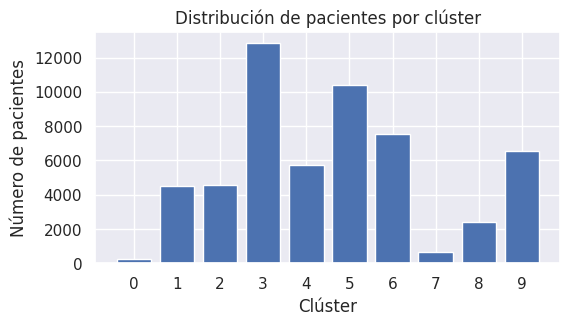

In [42]:
conteo_clusters = df_hn["Cluster"].value_counts().sort_index()

plt.figure(figsize=(6, 3))
plt.bar(conteo_clusters.index, conteo_clusters.values)

plt.xlabel("Clúster")
plt.ylabel("Pacientes")
plt.title("Pacientes por Clúster")
plt.xticks(range(10))
plt.show()

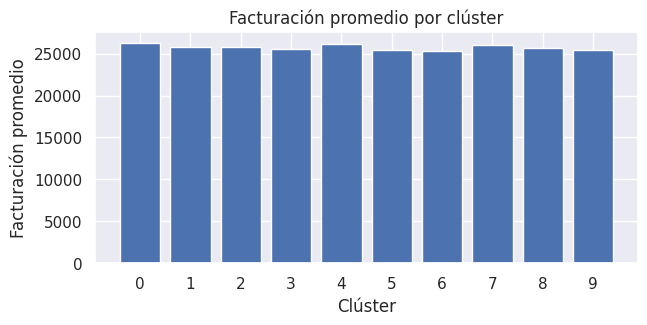

In [33]:
promedio_facturacion = df_hn.groupby("Cluster")["Billing Amount"].mean()

plt.figure(figsize=(7, 3))
plt.bar(promedio_facturacion.index, promedio_facturacion.values)

plt.xlabel("Clúster")
plt.ylabel("Facturación promedio")
plt.title("Facturación promedio por clúster")
plt.xticks(range(10))

plt.show()

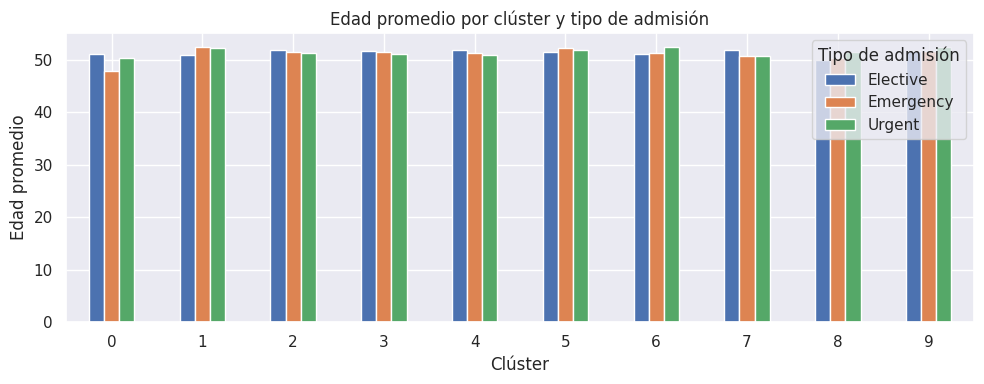

In [43]:
edad_admision = (df_hn.groupby(["Cluster", "Admission Type"])["Age"].mean().unstack())

edad_admision.plot(kind="bar", figsize=(10, 4))

plt.xlabel("Clúster")
plt.ylabel("Edad promedio")
plt.title("Edad promedio por clúster y tipo de admisión")
plt.xticks(rotation=0)
plt.legend(title="Tipo de admisión")
plt.tight_layout()
plt.show()

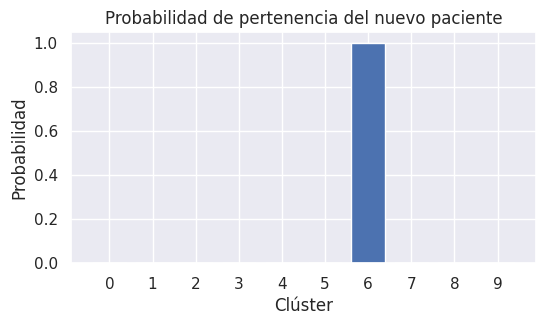

In [31]:
plt.figure(figsize=(6, 3))

plt.bar(range(10), probabilidades_np[0])

plt.xlabel("Clúster")
plt.ylabel("Probabilidad")
plt.title("Probabilidad de pertenencia del nuevo paciente")
plt.xticks(range(10))

plt.show()

In [ ]:
#Abajo los ejemplos de 5 y 20 componentes pero me que con 10 clúster

In [74]:
gmm_5 = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
gmm_5.fit(X_dense)
labels = gmm_5.predict(X_dense)                         # asignación dura (cluster más probable)
probabilidad = gmm_5.predict_proba(X_dense)             # asignación suave (probabilidades)

print('Pesos de la mezcla (pi_k):', np.round(gmm_5.weights_, 4))
print('Probabilidades de los 10 primeros pacientes:\n', np.round(probabilidad[:10], 6))

df_hn["Cluster"] = labels

print("\nCantidad de pacientes por cluster:") #Aportación de IA
print(df_hn["Cluster"].value_counts().sort_index())

Pesos de la mezcla (pi_k): [0.146  0.0668 0.197  0.0912 0.499 ]
Probabilidades de los 10 primeros pacientes:
 [[1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00]
 [1.84000e-04 0.00000e+00 9.99816e-01 0.00000e+00 0.00000e+00]
 [1.35000e-04 0.00000e+00 9.99865e-01 0.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00]
 [9.10000e-05 0.00000e+00 9.99909e-01 0.00000e+00 0.00000e+00]]

Cantidad de pacientes por cluster:
Cluster
0     8086
1     3699
2    10916
3     5053
4    27638
Name: count, dtype: int64


In [42]:
gmm_20 = GaussianMixture(n_components=20, covariance_type='full', random_state=42)
gmm_20.fit(X_dense)
labels = gmm_20.predict(X_dense)                         # asignación dura (cluster más probable)
probabilidad = gmm_20.predict_proba(X_dense)             # asignación suave (probabilidades)

print('Pesos de la mezcla (pi_k):', np.round(gmm_20.weights_, 4))
print('Probabilidades de los 10 primeros pacientes:\n', np.round(probabilidad[:10], 6))

df_hn["Cluster"] = labels

print("\nCantidad de pacientes por cluster:") #Aportación de IA
print(df_hn["Cluster"].value_counts().sort_index())

Pesos de la mezcla (pi_k): [0.0306 0.062  0.0186 0.1665 0.0157 0.0577 0.1674 0.0348 0.0197 0.0452
 0.0842 0.0268 0.0345 0.0104 0.015  0.0102 0.05   0.028  0.1026 0.0201]
Probabilidades de los 10 primeros pacientes:
 [[0.       0.       0.       0.       0.       0.       0.       0.
  0.       0.       0.       0.       0.       0.       1.       0.
  0.       0.       0.       0.      ]
 [0.       1.       0.       0.       0.       0.       0.       0.
  0.       0.       0.       0.       0.       0.       0.       0.
  0.       0.       0.       0.      ]
 [0.       0.       0.       1.       0.       0.       0.       0.
  0.       0.       0.       0.       0.       0.       0.       0.
  0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.       0.       0.
  0.       0.       0.982344 0.       0.       0.       0.       0.
  0.017656 0.       0.       0.      ]
 [0.       0.       0.       0.       0.       1.       0.       0.
  0.       0.   